In [13]:
import pandas as pd 
import numpy as np
import xarray as xr

In [14]:
# Start date 
start_date = '2024-08-06'
end_date = '2024-08-28' 

Dates = pd.date_range(start_date, end_date, freq='10s')

day=18
d1 = pd.to_datetime("2024-08-%02d 04:00" % day) 
d2 = pd.to_datetime("2024-08-%02d 21:00"% day)  
print("Day = ", day, " d1: ", d1, " d2: ", d2)

i0 = np.argwhere(Dates==d1)[0][0]
i1 = np.argwhere(Dates==d2)[0][0]   
print("\ni0: ", i0, " i1: ", i1)

# dates = dates[i0:i1+1]
chla = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2024/august6-28/microcystis_for_adjoint.csv")
chla1 = chla.loc[chla.model_time == i0]
# print(chla1)
init_conc = chla1.chla_smoothed 
print("\n\nSet initial concentration to: ", init_conc.values)

Day =  18  d1:  2024-08-18 04:00:00  d2:  2024-08-18 21:00:00

i0:  105120  i1:  111240


Set initial concentration to:  [1106.75593]


In [15]:
import xarray as xr 
import matplotlib.pyplot as plt
import cmocean as cmo 
import pandas as pd 

import numpy as np
import matplotlib.dates as mdates

def format_date_ax(ax):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)


chla2cell_mc =  1e-6/0.36  # ug chl-a/ml --> pg chl-a/ml --> 0.36  pg chl-a/cell Microcystis
chla2cell_diatom = 1e-6/4 # ug chl-a/ml --> pg chl-a/ml --> 4 pg chl-a/cell Diatom
cell2chla_mc = 1/chla2cell_mc
cell2chla_diatom = 1/chla2cell_diatom

In [16]:
NITER = 3

read_in = [1, NITER]

guess = {} 
for i in read_in: #range(1, NITER):
    guess[i] = xr.open_dataset('forward_phyto/forward_mc_%d_august_%01d.nc' % (i, day), decode_timedelta=False)

# Read in adjoint 
adjoint = {}
for i in read_in: #range(1, NITER):
    adjoint[i] = xr.open_dataset('backward_lambda/adjoint_mc_%d_august_%01d.nc' % (i, day), decode_timedelta=False)

z = guess[1]["z"]
print(adjoint[i].t.values[0],adjoint[i].t.values[-1])
dates = Dates[adjoint[i].t.values[0]:adjoint[i].t.values[-1]+1]
print(dates.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/pscratch/sd/s/siennaw/two_species/adjoint_phytoplankton/forward_phyto/forward_mc_1_august_18.nc'

(6122,) (60,) (6122, 60)


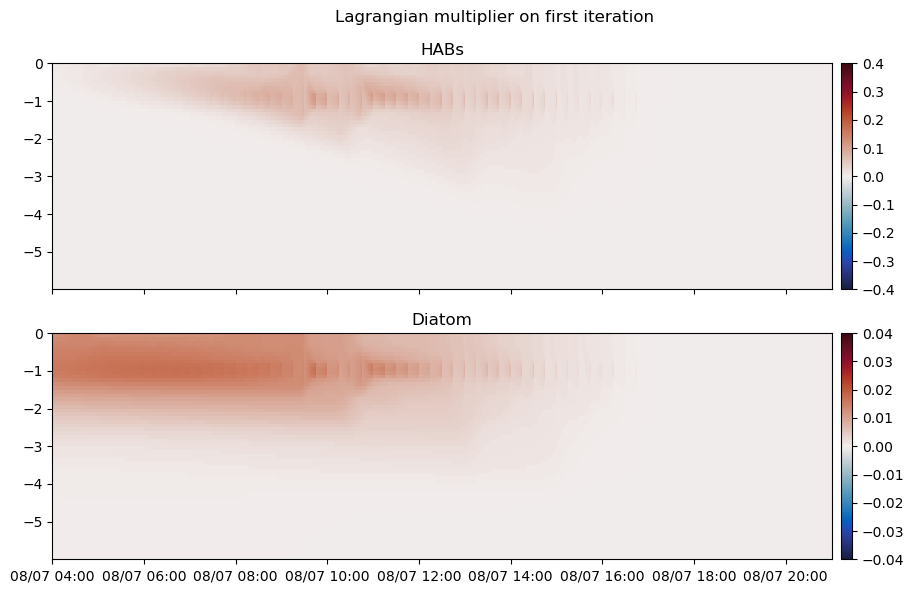

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True, sharey=True)

CLIM = 0.4

print(dates.shape, z.shape, adjoint[1]['lambda1'].values.shape)
c = axs[0].pcolormesh(dates, -z, adjoint[1]['lambda1'].values.T, cmap=cmo.cm.balance , vmax=CLIM, vmin=-CLIM, shading='auto')#, vmin=-1, vmax=1)
plt.colorbar(c, pad=0.01)
plt.suptitle('Lagrangian multiplier on first iteration')
axs[0].set_title("HABs")

c = axs[1].pcolormesh(dates, -z, adjoint[1]['lambda2'].values.T, cmap=cmo.cm.balance , vmax=CLIM/10, vmin=-CLIM/10)#, vmin=-1, vmax=1)
plt.colorbar(c, pad=0.01)
axs[1].set_title("Diatom")

axs[0].set_xlim(dates[0], dates[-1])
format_date_ax(axs[0])

plt.tight_layout()

4.4774809959263233e-07 3.022703620669227e-11
8.319251670045392e-06 3.007935364764089e-09


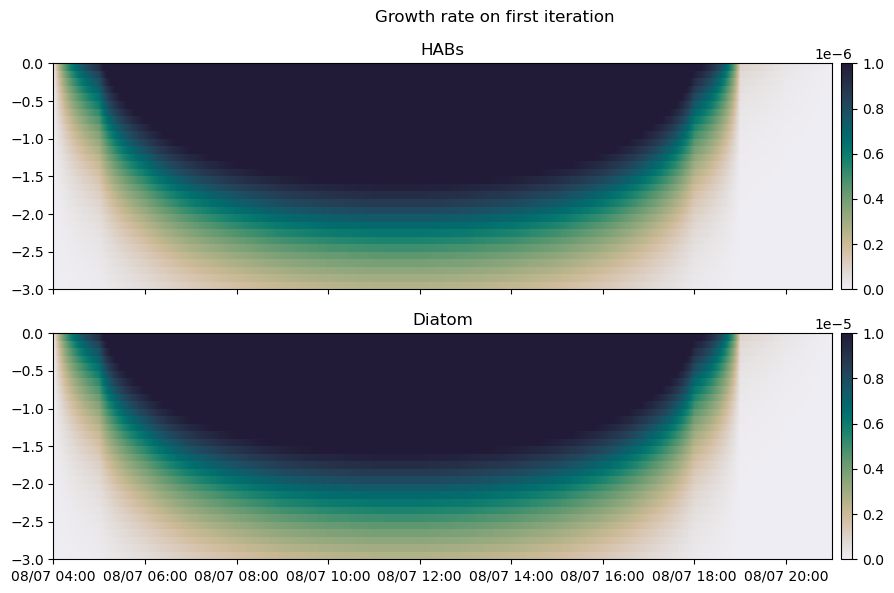

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True, sharey=True)

vmax = np.quantile(adjoint[NITER].gamma1.values.ravel(), 0.9)
vmin = np.quantile(adjoint[NITER].gamma1.values.ravel(), 0.1)
print(vmax, vmin)

vmax = np.quantile(adjoint[NITER].gamma2.values.ravel(), 0.9)
vmin = np.quantile(adjoint[NITER].gamma2.values.ravel(), 0.1)

print(vmax, vmin)

CLIM = 1e-5
c = axs[0].pcolormesh(dates, -z, guess[1].gamma1.values.T, cmap=cmo.cm.rain , vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
plt.colorbar(c, pad=0.01)
plt.suptitle('Growth rate on first iteration')
axs[0].set_title("HABs")

c = axs[1].pcolormesh(dates, -z, guess[1].gamma2.values.T, cmap=cmo.cm.rain , vmax=CLIM, vmin=0)#, vmin=-1, vmax=1)
plt.colorbar(c, pad=0.01)
axs[1].set_title("Diatom")

axs[0].set_xlim(dates[0], dates[-1])
format_date_ax(axs[0])
axs[0].set_ylim(-3, 0)

plt.tight_layout()

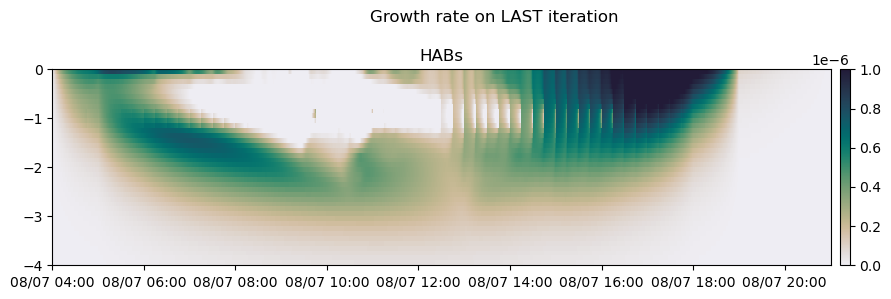

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 3), sharex=True, sharey=True)
CLIM = 1e-5
c = axs.pcolormesh(dates, -z, guess[NITER].gamma1.values.T, cmap=cmo.cm.rain , vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
plt.colorbar(c, pad=0.01)
plt.suptitle('Growth rate on LAST iteration')
axs.set_title("HABs")

# axs[0].set_xlim(dates[1000], dates[-1000])
format_date_ax(axs)
axs.set_ylim(-4, 0)

plt.tight_layout()

0      2024-08-06 00:00:00
1      2024-08-06 00:15:00
2      2024-08-06 00:30:00
3      2024-08-06 00:45:00
4      2024-08-06 01:00:00
               ...        
2058   2024-08-27 22:45:00
2059   2024-08-27 23:00:00
2060   2024-08-27 23:15:00
2061   2024-08-27 23:30:00
2062   2024-08-27 23:45:00
Name: time, Length: 2063, dtype: datetime64[ns]
0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
2058   NaN
2059   NaN
2060   NaN
2061   NaN
2062   NaN
Name: chla_smoothed, Length: 2063, dtype: float64


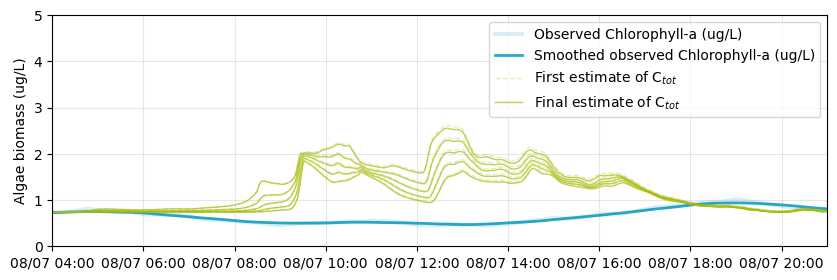

In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

# Chlorophyll-a data
chla = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2024/august6-28/microcystis_for_adjoint.csv")
chla['time'] = pd.to_datetime(chla['time'])
hab = chla.chla_smoothed 
ax.plot(chla.time, hab*1e-3, color="#0998BC", alpha=0.15, linewidth=3, label='Observed Chlorophyll-a (ug/L)')

# Rolling average to smooth the data
hab = hab.rolling(window=10, center=True).mean()
ax.plot(chla.time, hab*1e-3, color="#0998BC", alpha=0.85, linewidth=2, label='Smoothed observed Chlorophyll-a (ug/L)')
print(chla.time)
print(hab)

for i in range(48,53): 
    one_meter_data_1 = guess[1].isel(z=i)
    one_meter_data_N = guess[NITER].isel(z=i)

    # one_meter_data_1 = guess[1].isel(z=slice(50,52)).mean(dim='z')
    # one_meter_data_N = guess[NITER].isel(z=slice(50,52)).mean(dim='z')

    # First 
    total = one_meter_data_1['algae1'].values.T*cell2chla_mc #+ one_meter_data_1['algae2'].values.T*cell2chla_diatom
    ax.plot(dates[0:-1], total[0:-1]*1e-3, '--',  color='#A6BC09', linewidth=1, alpha=0.27)

    # End 
    total = one_meter_data_N['algae1'].values.T*cell2chla_mc #+ one_meter_data_N['algae2'].values.T*cell2chla_diatom
    ax.plot(dates[0:-2], total[0:-2]*1e-3, '-',  color='#A6BC09', linewidth=1, alpha=0.7)
    
    # total = one_meter_data_N['algae1'].values.T*cell2chla_mc 
    # ax.plot(dates[0:-2], total[0:-2], '--',  color="#1E09BC", linewidth=1, alpha=0.7)

        
    # total = one_meter_data_N['algae2'].values.T*cell2chla_diatom 
    # ax.plot(dates[0:-2], total[0:-2], '--',  color="#BC093F", linewidth=1, alpha=0.7)

ax.plot([], [], '--', label=r'First estimate of C$_{tot}$', color='#A6BC09', linewidth=1, alpha=0.27)
ax.plot([], [], '-', label=r'Final estimate of C$_{tot}$', color='#A6BC09', linewidth=1, alpha=0.7)

ax.set_xlim(dates[0], dates[-1])
ax.set_ylim(0, 5)
format_date_ax(ax)
ax.grid(alpha=0.3)
ax.set_ylabel("Algae biomass (ug/L)")
ax.legend()

# plt.suptitle("Comparing algae concentration from the model to mapping data @ 1m")
# plt.tight_layout()
# ax.plot(dates[0:-2], one_meter_data_N['algae1'].values.T[0:-2], '--', label='HAB', color='#ED8B16', linewidth=3, alpha=0.3)
# ax.plot(dates[0:-2], one_meter_data_N['algae2'].values.T[0:-2], '--', label='Diatom', color='#A6BC09', linewidth=3, alpha=0.3)

0.0020722222222222223
0.0
0.0020722222222222223
0.0
0.0020722222222222223
0.0
0.0020722222222222223
0.0
0.0020722222222222223
0.0


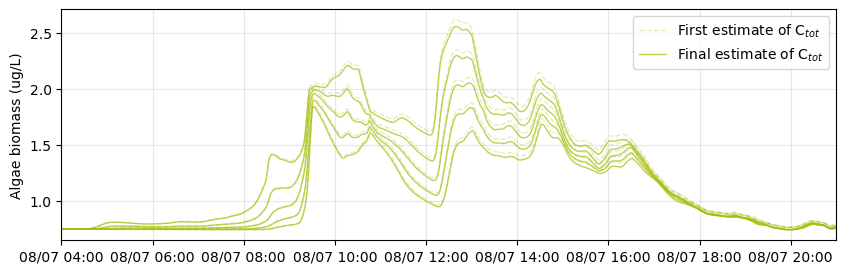

In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

for i in range(48,53): 
    one_meter_data_1 = guess[1].isel(z=i)
    one_meter_data_N = guess[NITER].isel(z=i)

    # First 
    algae1 = one_meter_data_1['algae1'].values.T*cell2chla_mc *1e-3
    algae2 = one_meter_data_1['algae2'].values.T*cell2chla_diatom*1e-3
    ax.plot(dates[0:-1], algae1[0:-1], '--',  color='#A6BC09', linewidth=1, alpha=0.27)

    # End 
    print(one_meter_data_N['algae1'].values[0])
    print(one_meter_data_N['algae2'].values[0])
    
    total = one_meter_data_N['algae1'].values.T*cell2chla_mc 
    # total = one_meter_data_N['algae2'].values.T*cell2chla_diatom
    ax.plot(dates[0:-2], total[0:-2]*1e-3, '-',  color='#A6BC09', linewidth=1, alpha=0.7)
    
    # total = one_meter_data_N['algae1'].values.T*cell2chla_mc 
    # ax.plot(dates[0:-2], total[0:-2], '--',  color="#1E09BC", linewidth=1, alpha=0.7)

        
    # total = one_meter_data_N['algae2'].values.T*cell2chla_diatom 
    # ax.plot(dates[0:-2], total[0:-2], '--',  color="#BC093F", linewidth=1, alpha=0.7)

ax.plot([], [], '--', label=r'First estimate of C$_{tot}$', color='#A6BC09', linewidth=1, alpha=0.27)
ax.plot([], [], '-', label=r'Final estimate of C$_{tot}$', color='#A6BC09', linewidth=1, alpha=0.7)

ax.set_xlim(dates[0], dates[-1])
# ax.set_ylim(3, 25)
format_date_ax(ax)
ax.grid(alpha=0.3)
ax.set_ylabel("Algae biomass (ug/L)")
ax.legend()

# plt.suptitle("Comparing algae concentration from the model to mapping data @ 1m")
# plt.tight_layout()
# ax.plot(dates[0:-2], one_meter_data_N['algae1'].values.T[0:-2], '--', label='HAB', color='#ED8B16', linewidth=3, alpha=0.3)
# ax.plot(dates[0:-2], one_meter_data_N['algae2'].values.T[0:-2], '--', label='Diatom', color='#A6BC09', linewidth=3, alpha=0.3)

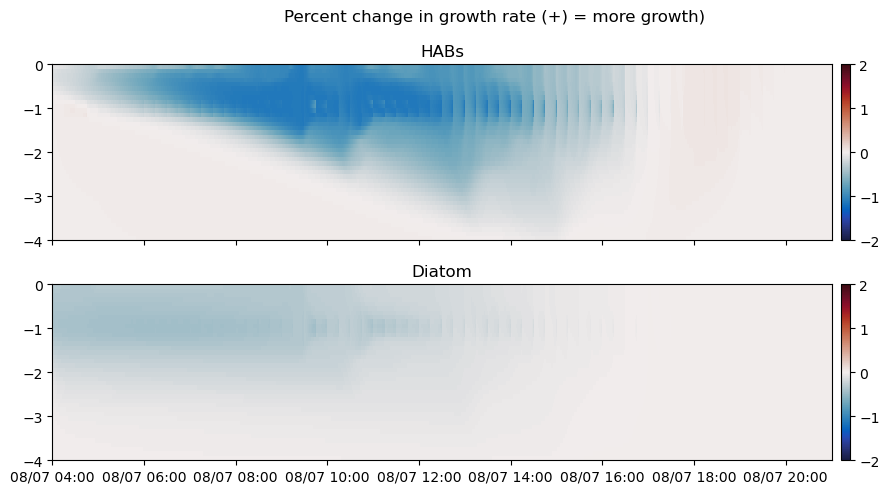

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), sharex=True, sharey=True)


CLIM = 2
difference = (guess[NITER].gamma1.values.T - guess[1].gamma1.values.T )/(guess[1].gamma1.values.T +1e-8)
c = axs[0].pcolormesh(dates, -z, difference, cmap=cmo.cm.balance , vmax=CLIM, vmin=-CLIM)#, vmin=-1, vmax=1)
plt.colorbar(c, pad=0.01)
plt.suptitle('Percent change in growth rate (+) = more growth)')
axs[0].set_title("HABs")


CLIM = 2
difference = (guess[NITER].gamma2.values.T - guess[1].gamma2.values.T )/(guess[1].gamma2.values.T+1e-8) 
c = axs[1].pcolormesh(dates, -z, difference, cmap=cmo.cm.balance , vmax=CLIM, vmin=-CLIM)#, vmin=-1, vmax=1)
plt.colorbar(c, pad=0.01)
axs[1].set_title("Diatom")

axs[0].set_xlim(dates[0], dates[-1])
format_date_ax(axs[0])
axs[0].set_ylim(-4, 0)

plt.tight_layout()